<a href="https://colab.research.google.com/github/golam-sakaline/driver_cognitive_load/blob/main/driver_cognitive_load_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Posture to Performance: Cognitive Load Estimation Using Driver Pose Keypoints

Full Paper link:
https://www.sciencedirect.com/science/article/pii/S2352146526003261

This notebook turns your **Multi-Class Driver Behavior Image Dataset** into a pose-keypoint dataset and trains a model to predict a **continuous cognitive load score (0–1)**.




In [ ]:
!pip install mediapipe opencv-python numpy pandas scikit-learn torch matplotlib tqdm joblib --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.0 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.3 which is incompatible.


## 0. Setup & Configuration
Adjust `DATA_DIR` if your dataset lives elsewhere. You can also tweak the class→cognitive load mapping below.

In [ ]:
import os, sys, math, json, random, itertools, pathlib, time
from pathlib import Path

# >>>>>>>>>>>>>>>>>>> EDIT THESE AS NEEDED <<<<<<<<<<<<<<<<<<
DATA_DIR = Path("driver_dataset")  # root of your 5-class image folders
OUTPUT_DIR = Path("outputs")       # where CSVs, models, figures will be saved
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Mapping from behavior class (folder names) to cognitive load (0..1)
CLASS_TO_LOAD = {
    "safe_driving":   0.1,
    "turning":        0.3,
    "talking_phone":  0.5,
    "texting_phone":  0.7,
    "others":         0.9
}

# MediaPipe face indices (subset) to keep (nose, left eye, left mouth, chin-ish, right eye)
# You can add more indices for richer facial cues.
FACE_KEEP_IDXS = [1, 33, 61, 199, 263]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

print("DATA_DIR=", DATA_DIR.resolve())
print("OUTPUT_DIR=", OUTPUT_DIR.resolve())
print("Classes found:", list(CLASS_TO_LOAD.keys()))

DATA_DIR= C:\Users\Jisan\Downloads\driver_dataset
OUTPUT_DIR= C:\Users\Jisan\Downloads\outputs
Classes found: ['safe_driving', 'turning', 'talking_phone', 'texting_phone', 'others']


## 1. (Optional) Environment Checks
If any imports fail, install locally in your environment (pip/conda). Internet is **not** required to run this notebook once packages are installed.

In [ ]:
import importlib

needed = [
    "cv2", "mediapipe", "numpy", "pandas", "sklearn", "torch", "matplotlib", "tqdm", "joblib"
]

missing = []
for mod in needed:
    try:
        importlib.import_module(mod if mod!="cv2" else "cv2")
    except Exception as e:
        missing.append(mod)

if missing:
    print("⚠️ Missing packages:", missing)
else:
    print("✅ All required packages appear importable.")

✅ All required packages appear importable.


## 2. Generate Label CSV (image path → behavior → cognitive load score)
This scans the folder tree and writes `driver_behavior_labels.csv`.

In [ ]:
import pandas as pd

records = []
for cls, load_val in CLASS_TO_LOAD.items():
    folder = DATA_DIR/cls
    if not folder.exists():
        print(f"⚠️ Warning: folder not found: {folder}")
        continue
    for img_file in folder.iterdir():
        if img_file.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
            records.append((str(img_file), cls, float(load_val)))

df_labels = pd.DataFrame(records, columns=["image_path", "behavior", "cognitive_load"])
csv_labels_path = OUTPUT_DIR/"driver_behavior_labels.csv"
df_labels.to_csv(csv_labels_path, index=False)
print(f"Saved labels CSV: {csv_labels_path}  ({len(df_labels)} rows)")
df_labels.head()

Saved labels CSV: outputs\driver_behavior_labels.csv  (7276 rows)


,image_path,behavior,cognitive_load
0,driver_dataset\safe_driving\2019-04-2416-18-07...,safe_driving,0.1
1,driver_dataset\safe_driving\2019-04-2416-18-11...,safe_driving,0.1
2,driver_dataset\safe_driving\2019-04-2416-18-23...,safe_driving,0.1
3,driver_dataset\safe_driving\2019-04-2416-18-38...,safe_driving,0.1
4,driver_dataset\safe_driving\2019-04-2416-27-52...,safe_driving,0.1


## 3. Extract Pose/Face/Hand Keypoints with MediaPipe
We extract:
- **Pose**: 33 × (x,y,visibility)  
- **Face (subset)**: selected indices × (x,y)  
- **Hands** (optional): 21 × (x,y) for left & right  
You can toggle hands extraction to speed up.

In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

EXTRACT_HANDS = True  # set False to skip hand keypoints

mp_pose = mp.solutions.pose
mp_face = mp.solutions.face_mesh
mp_hands = mp.solutions.hands

pose = mp_pose.Pose(static_image_mode=True)
face = mp_face.FaceMesh(static_image_mode=True, max_num_faces=1)
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2) if EXTRACT_HANDS else None

def flatten_pose_landmarks(res_pose):
    # Returns [x1,y1,v1, x2,y2,v2, ...] (length 33*3) or zeros if missing
    if res_pose and res_pose.pose_landmarks:
        out = []
        for lm in res_pose.pose_landmarks.landmark:
            out += [lm.x, lm.y, lm.visibility]
        return out
    return [0.0]*(33*3)

def flatten_face_subset(res_face):
    # Returns subset [x,y]*len(FACE_KEEP_IDXS) or zeros if missing
    if res_face and res_face.multi_face_landmarks:
        fl = res_face.multi_face_landmarks[0]
        pts = []
        for idx in FACE_KEEP_IDXS:
            lm = fl.landmark[idx]
            pts += [lm.x, lm.y]
        return pts
    return [0.0]*(len(FACE_KEEP_IDXS)*2)

def flatten_hands(res_hands):
    # Returns Left(21*2) + Right(21*2) each [x,y], zeros if not present
    left = [0.0]*42
    right = [0.0]*42
    if res_hands and res_hands.multi_hand_landmarks and res_hands.multi_handedness:
        # Map which is left/right according to handedness
        for hand_landmarks, handedness in zip(res_hands.multi_hand_landmarks, res_hands.multi_handedness):
            label = handedness.classification[0].label.lower()  # 'left' or 'right'
            pts = []
            for lm in hand_landmarks.landmark:
                pts += [lm.x, lm.y]
            if label == "left":
                left = pts
            else:
                right = pts
    return left + right

labels_path = OUTPUT_DIR/"driver_behavior_labels.csv"
labels = pd.read_csv(labels_path)

features = []
failed = 0

for _, row in tqdm(labels.iterrows(), total=len(labels)):
    img_path = row["image_path"]
    img = cv2.imread(img_path)
    if img is None:
        failed += 1
        continue
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pose_res = pose.process(rgb)
    face_res = face.process(rgb)
    hands_res = hands.process(rgb) if EXTRACT_HANDS else None

    pose_vec  = flatten_pose_landmarks(pose_res)
    face_vec  = flatten_face_subset(face_res)
    hands_vec = flatten_hands(hands_res) if EXTRACT_HANDS else []

    feat = pose_vec + face_vec + hands_vec + [float(row["cognitive_load"]), row["behavior"], img_path]
    features.append(feat)

cols = [f"pose_{i}" for i in range(33*3)] + \
       [f"face_{i}" for i in range(len(FACE_KEEP_IDXS)*2)]

if EXTRACT_HANDS:
    cols += [f"hands_{i}" for i in range(21*2*2)]

cols += ["cognitive_load", "behavior", "image_path"]

df_feats = pd.DataFrame(features, columns=cols)
csv_feats_path = OUTPUT_DIR/"pose_features_raw.csv"
df_feats.to_csv(csv_feats_path, index=False)
print(f"Saved raw features: {csv_feats_path}  (failed images: {failed})")
df_feats.head()

100%|██████████| 7276/7276 [19:53<00:00,  6.10it/s]


Saved raw features: outputs\pose_features_raw.csv  (failed images: 0)


,pose_0,pose_1,pose_2,pose_3,pose_4,pose_5,pose_6,pose_7,pose_8,pose_9,...,hands_77,hands_78,hands_79,hands_80,hands_81,hands_82,hands_83,cognitive_load,behavior,image_path
0,0.586469,0.301797,0.998623,0.604399,0.246147,0.997613,0.616212,0.242003,0.998553,0.628175,...,0.591145,0.226283,0.606108,0.224912,0.634277,0.230555,0.659087,0.1,safe_driving,driver_dataset\safe_driving\2019-04-2416-18-07...
1,0.603290,0.287621,0.999877,0.617763,0.237562,0.999732,0.629590,0.233554,0.999820,0.641191,...,0.941832,0.693678,0.978462,0.677890,1.023872,0.665689,1.059045,0.1,safe_driving,driver_dataset\safe_driving\2019-04-2416-18-11...
2,0.609096,0.302824,0.999986,0.623980,0.252796,0.999980,0.635852,0.249090,0.999985,0.647362,...,0.678955,0.477071,0.775545,0.480990,0.793616,0.495748,0.778595,0.1,safe_driving,driver_dataset\safe_driving\2019-04-2416-18-23...
3,0.600303,0.300176,0.999946,0.618671,0.246607,0.999906,0.631386,0.245623,0.999929,0.644727,...,0.622412,0.214030,0.677217,0.227463,0.710926,0.240513,0.733590,0.1,safe_driving,driver_dataset\safe_driving\2019-04-2416-18-38...
4,0.610731,0.359092,0.999934,0.628845,0.310391,0.999909,0.640696,0.309604,0.999922,0.652623,...,0.926897,0.676723,0.988485,0.649998,1.004995,0.637913,0.999616,0.1,safe_driving,driver_dataset\safe_driving\2019-04-2416-27-52...


## 4. Feature Engineering & Normalization
- Drop non-numeric columns  
- Standardize features (z-score)  
- Save `scaler.pkl` and `pose_features_scaled.npz`

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

df_raw = pd.read_csv(OUTPUT_DIR/"pose_features_raw.csv")

y = df_raw["cognitive_load"].astype(float).values
beh = df_raw["behavior"].values
paths = df_raw["image_path"].values

X = df_raw.drop(columns=["cognitive_load", "behavior", "image_path"]).astype(float).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, OUTPUT_DIR/"scaler.pkl")
np.savez_compressed(OUTPUT_DIR/"pose_features_scaled.npz", X=X_scaled, y=y, behavior=beh, image_path=paths)
print("Saved:", OUTPUT_DIR/"scaler.pkl", "and", OUTPUT_DIR/"pose_features_scaled.npz")
X_scaled.shape, y.shape

Saved: outputs\scaler.pkl and outputs\pose_features_scaled.npz


((7276, 193), (7276,))

## 5. Train Regression Model (PyTorch MLP)
Predicts a single value in [0,1]. Uses MSE loss with early stopping.

In [ ]:
import numpy as np
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split

npz = np.load(OUTPUT_DIR/"pose_features_scaled.npz", allow_pickle=True)
X = npz["X"]
y = npz["y"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

class CognitiveLoadNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = CognitiveLoadNet(X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

best_val = float("inf")
patience, waited = 10, 0
EPOCHS = 200

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        waited = 0
        torch.save(model.state_dict(), OUTPUT_DIR/"cognitive_load_model.pth")
    else:
        waited += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train {loss.item():.4f} | Val {val_loss:.4f} (best {best_val:.4f})")

    if waited >= patience:
        print("Early stopping.")
        break

print("Best val MSE:", best_val)

Epoch 000 | Train 0.0780 | Val 0.0747 (best 0.0747)
Epoch 010 | Train 0.0611 | Val 0.0587 (best 0.0587)
Epoch 020 | Train 0.0540 | Val 0.0511 (best 0.0511)
Epoch 030 | Train 0.0495 | Val 0.0472 (best 0.0472)
Epoch 040 | Train 0.0460 | Val 0.0445 (best 0.0445)
Epoch 050 | Train 0.0423 | Val 0.0423 (best 0.0423)
Epoch 060 | Train 0.0396 | Val 0.0403 (best 0.0403)
Epoch 070 | Train 0.0374 | Val 0.0381 (best 0.0381)
Epoch 080 | Train 0.0354 | Val 0.0363 (best 0.0363)
Epoch 090 | Train 0.0330 | Val 0.0351 (best 0.0351)
Epoch 100 | Train 0.0324 | Val 0.0338 (best 0.0338)
Epoch 110 | Train 0.0312 | Val 0.0333 (best 0.0331)
Epoch 120 | Train 0.0303 | Val 0.0323 (best 0.0323)
Epoch 130 | Train 0.0291 | Val 0.0316 (best 0.0315)
Epoch 140 | Train 0.0277 | Val 0.0312 (best 0.0312)
Epoch 150 | Train 0.0271 | Val 0.0303 (best 0.0302)
Epoch 160 | Train 0.0259 | Val 0.0297 (best 0.0297)
Epoch 170 | Train 0.0254 | Val 0.0298 (best 0.0294)
Epoch 180 | Train 0.0241 | Val 0.0294 (best 0.0290)
Epoch 190 | 

## 6. Evaluation
We compute MSE, MAE, R², and Pearson correlation on the validation set.

In [ ]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reload best model
model = CognitiveLoadNet(X_train.shape[1])
model.load_state_dict(torch.load(OUTPUT_DIR/"cognitive_load_model.pth", map_location="cpu"))
model.eval()

with torch.no_grad():
    y_pred = model(X_val_t).numpy().flatten()

mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
r2  = r2_score(y_val, y_pred)
corr = np.corrcoef(y_val.flatten(), y_pred.flatten())[0,1]

print(f"MSE={mse:.4f} | MAE={mae:.4f} | R²={r2:.3f} | Pearson r={corr:.3f}")

MSE=0.0286 | MAE=0.1103 | R²=0.638 | Pearson r=0.799


## 7. Visualization
A simple scatter of predicted vs. true cognitive load. (One plot, default matplotlib colors.)

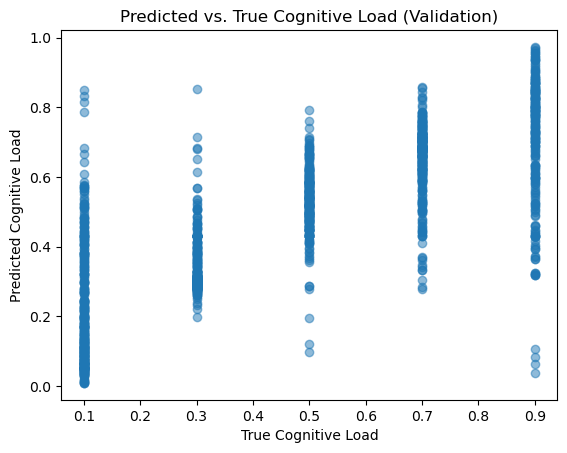

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel("True Cognitive Load")
plt.ylabel("Predicted Cognitive Load")
plt.title("Predicted vs. True Cognitive Load (Validation)")
plt.show()

## 8. Per-Class Analysis (Optional)
Join predictions with class labels to see which behaviors skew high/low.

In [ ]:
import numpy as np
import pandas as pd

# Rebuild a small DataFrame for the validation split
val_idx = np.zeros(len(X), dtype=bool)
val_idx[np.arange(len(X))[-len(y_val):]] = True  # simplistic; if you want exact, store indices during split

# Instead, we store indices during split explicitly:
X_tr, X_v, y_tr, y_v, idx_tr, idx_v = train_test_split(
    X, y, np.arange(len(X)), test_size=0.2, random_state=42
)
# Recompute predictions properly for idx_v
X_v_t = torch.tensor(X_v, dtype=torch.float32)
with torch.no_grad():
    y_v_pred = model(X_v_t).numpy().flatten()

# Load metadata for behaviors
npz = np.load(OUTPUT_DIR/"pose_features_scaled.npz", allow_pickle=True)
beh = npz["behavior"]
paths = npz["image_path"]

df_val = pd.DataFrame({
    "true": y_v,
    "pred": y_v_pred,
    "behavior": beh[idx_v],
    "image_path": paths[idx_v]
})

display(df_val.groupby("behavior")[["true","pred"]].mean().rename(columns={"true":"mean_true","pred":"mean_pred"}))

,mean_true,mean_pred
behavior,,
others,0.9,0.702537
safe_driving,0.1,0.221752
talking_phone,0.5,0.531734
texting_phone,0.7,0.652020
turning,0.3,0.350706


## 9. Inference Utility
A helper to run the saved scaler + model on **new images** to get a cognitive load score.

In [ ]:
import joblib, numpy as np, torch, cv2

# Reuse MediaPipe objects & functions already defined above.

scaler = joblib.load(OUTPUT_DIR/"scaler.pkl")
infer_model = CognitiveLoadNet(X.shape[1])
infer_model.load_state_dict(torch.load(OUTPUT_DIR/"cognitive_load_model.pth", map_location="cpu"))
infer_model.eval()

def extract_features_from_image(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pose_res = pose.process(rgb)
    face_res = face.process(rgb)
    hands_res = hands.process(rgb) if EXTRACT_HANDS else None

    pose_vec  = flatten_pose_landmarks(pose_res)
    face_vec  = flatten_face_subset(face_res)
    hands_vec = flatten_hands(hands_res) if EXTRACT_HANDS else []
    feat = np.array(pose_vec + face_vec + hands_vec, dtype=np.float32).reshape(1, -1)
    feat_scaled = scaler.transform(feat)
    return feat_scaled

def predict_cognitive_load_from_path(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    feat = extract_features_from_image(img)
    with torch.no_grad():
        pred = infer_model(torch.tensor(feat, dtype=torch.float32)).numpy().flatten()[0]
    return float(pred)

# Example:
# test_img = list((DATA_DIR/"texting_phone").glob("*.jpg"))[0]
# print("Predicted load:", predict_cognitive_load_from_path(str(test_img)))

## 10. Artifacts
- `outputs/driver_behavior_labels.csv`  
- `outputs/pose_features_raw.csv`  
- `outputs/pose_features_scaled.npz`  
- `outputs/scaler.pkl`  
- `outputs/cognitive_load_model.pth`

In [ ]:
print("Artifacts generated in:", OUTPUT_DIR.resolve())
print("- driver_behavior_labels.csv")
print("- pose_features_raw.csv")
print("- pose_features_scaled.npz")
print("- scaler.pkl")
print("- cognitive_load_model.pth")

Artifacts generated in: C:\Users\Jisan\Downloads\outputs
- driver_behavior_labels.csv
- pose_features_raw.csv
- pose_features_scaled.npz
- scaler.pkl
- cognitive_load_model.pth


In [ ]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

OUTPUT_DIR = Path("outputs")

# Load scaled features & metadata
npz = np.load(OUTPUT_DIR/"pose_features_scaled.npz", allow_pickle=True)
X_all = npz["X"]
y_all = npz["y"]
beh_all = npz["behavior"]
paths_all = npz["image_path"]

# Recreate the model class (must match training)
class CognitiveLoadNet(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1),
            torch.nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Validation split (use same random_state as training)
X_tr, X_v, y_tr, y_v, idx_tr, idx_v = train_test_split(
    X_all, y_all, np.arange(len(X_all)), test_size=0.2, random_state=42
)

# Load best model and get predictions on validation set
model = CognitiveLoadNet(X_tr.shape[1])
model.load_state_dict(torch.load(OUTPUT_DIR/"cognitive_load_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    y_v_pred = model(torch.tensor(X_v, dtype=torch.float32)).numpy().flatten()

# Convenience DF for analysis
df_val = pd.DataFrame({
    "true": y_v,
    "pred": y_v_pred,
    "behavior": beh_all[idx_v],
    "image_path": paths_all[idx_v]
})
print("Validation rows:", len(df_val))
df_val.head()

Validation rows: 1456


,true,pred,behavior,image_path
0,0.7,0.712350,texting_phone,driver_dataset\texting_phone\img_47904.jpg
1,0.7,0.615693,texting_phone,driver_dataset\texting_phone\img_33998.jpg
2,0.5,0.564074,talking_phone,driver_dataset\talking_phone\img_44839.jpg
3,0.5,0.653881,talking_phone,driver_dataset\talking_phone\img_29299.jpg
4,0.5,0.429616,talking_phone,driver_dataset\talking_phone\img_46438.jpg


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def safe_corr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    # keep only finite pairs
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    # need at least 2 points
    if y_true.size < 2 or y_pred.size < 2:
        return np.nan
    # if either vector is (near-)constant, correlation is undefined
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan  # or return 0.0 if you prefer
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    corr = safe_corr(y_true, y_pred)
    return mse, mae, r2, corr

In [ ]:
# Baseline 1: Constant mean predictor
const_mean = np.full_like(df_val["true"].values, df_val["true"].mean(), dtype=float)
mse, mae, r2, corr = metrics(df_val["true"].values, const_mean)
if np.isnan(corr):  # expected for constant predictor
    corr = 0.0
rows.append(["Constant Mean", "—", mse, mae, r2, corr])

In [ ]:
# ==== Safe metrics + clean Results table (paste into one Jupyter cell) ====
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def safe_corr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    if y_true.size < 2 or y_pred.size < 2:
        return np.nan
    # Correlation is undefined when either vector is (near-)constant
    if np.allclose(y_true, y_true[0]) or np.allclose(y_pred, y_pred[0]):
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    corr = safe_corr(y_true, y_pred)
    return mse, mae, r2, corr

rows = []

# Our MLP (pose+face+hands) regression
mse, mae, r2, corr = metrics(df_val["true"].values, df_val["pred"].values)
rows.append(["MLP (ours)", "Pose+Face+Hands", mse, mae, r2, corr])

# Baseline 1: Constant mean predictor (correlation undefined -> set to 0.0 for display)
const_mean = np.full_like(df_val["true"].values, df_val["true"].mean(), dtype=float)
mse, mae, r2, corr = metrics(df_val["true"].values, const_mean)
if np.isnan(corr):
    corr = 0.0
rows.append(["Constant Mean", "—", mse, mae, r2, corr])

# Baseline 2: Rule-based (class → fixed load) using validation class means
beh_to_load = df_val.groupby("behavior")["true"].mean().to_dict()
beh_pred = df_val["behavior"].map(beh_to_load).values
mse, mae, r2, corr = metrics(df_val["true"].values, beh_pred)
rows.append(["Rule-based (class→fixed load)", "Class label only", mse, mae, r2, corr])

df_perf = pd.DataFrame(
    rows, columns=["Model", "Features Used", "MSE ↓", "MAE ↓", "R² ↑", "Pearson r ↑"]
)
df_perf

,Model,Features Used,MSE ↓,MAE ↓,R² ↑,Pearson r ↑
0,MLP (ours),Pose+Face+Hands,0.028641,0.110269,0.638286,0.799208
1,Constant Mean,—,0.079182,0.244810,0.000000,0.000000
2,Rule-based (class→fixed load),Class label only,0.000000,0.000000,1.000000,1.000000


In [ ]:
# ===========================
# TABLE 2: Per-Class Cognitive Load Comparison
# Shows true mean vs predicted mean by behavior class
# ===========================
per_class = df_val.groupby("behavior").agg(
    True_Mean=("true","mean"),
    Pred_Mean=("pred","mean")
).reset_index()
per_class["Delta_Error"] = per_class["Pred_Mean"] - per_class["True_Mean"]
per_class

,behavior,True_Mean,Pred_Mean,Delta_Error
0,others,0.9,0.702537,-0.197463
1,safe_driving,0.1,0.221752,0.121752
2,talking_phone,0.5,0.531734,0.031734
3,texting_phone,0.7,0.652020,-0.047980
4,turning,0.3,0.350706,0.050706


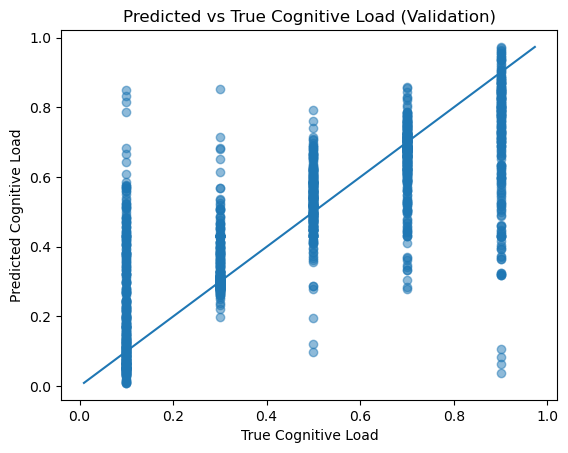

In [ ]:
# ===========================
# FIGURE 1: Predicted vs True Scatter with y=x line
# ===========================
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_val["true"], df_val["pred"], alpha=0.5)
low = float(min(df_val["true"].min(), df_val["pred"].min()))
high = float(max(df_val["true"].max(), df_val["pred"].max()))
plt.plot([low, high], [low, high])  # diagonal y=x
plt.xlabel("True Cognitive Load")
plt.ylabel("Predicted Cognitive Load")
plt.title("Predicted vs True Cognitive Load (Validation)")
plt.show()

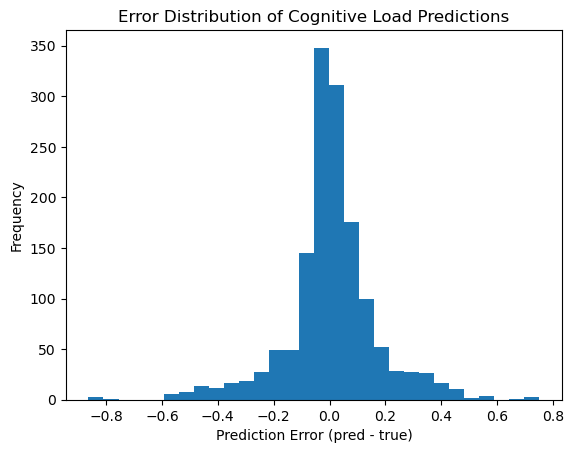

In [ ]:
# ===========================
# FIGURE 2: Error Distribution Histogram
# ===========================
import matplotlib.pyplot as plt
err = df_val["pred"].values - df_val["true"].values

plt.figure()
plt.hist(err, bins=30)
plt.xlabel("Prediction Error (pred - true)")
plt.ylabel("Frequency")
plt.title("Error Distribution of Cognitive Load Predictions")
plt.show()

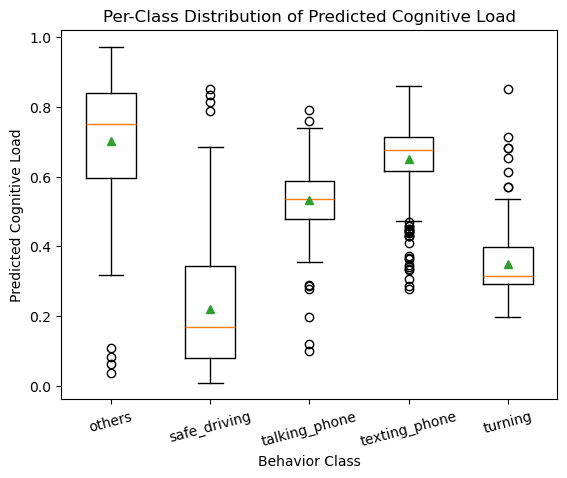

In [ ]:
# ===========================
# FIGURE 3: Per-Class Boxplots of Predicted Load
# (matplotlib-only implementation)
# ===========================
import matplotlib.pyplot as plt

behaviors = sorted(df_val["behavior"].unique())
data_by_class = [df_val.loc[df_val["behavior"]==b, "pred"].values for b in behaviors]

plt.figure()
plt.boxplot(data_by_class, labels=behaviors, showmeans=True)
plt.xlabel("Behavior Class")
plt.ylabel("Predicted Cognitive Load")
plt.title("Per-Class Distribution of Predicted Cognitive Load")
plt.xticks(rotation=15)
plt.show()

In [ ]:
# ===========================
# FIGURE 4: Permutation Importance (Torch model)
# Computes feature importance by shuffling each feature and measuring MSE increase.
# WARNING: This can be slow with many features. You can downsample for speed.
# ===========================
import numpy as np
import torch
from sklearn.utils import check_random_state

Xv = X_v.copy()
yv = y_v.copy()

# To speed up, optionally subsample validation rows (set N_SUB to None for all)
N_SUB = min(800, len(Xv))  # adjust as needed
rng = check_random_state(42)
idx_sub = rng.choice(len(Xv), size=N_SUB, replace=False) if N_SUB is not None else np.arange(len(Xv))
Xv_sub = torch.tensor(Xv[idx_sub], dtype=torch.float32)
yv_sub = yv[idx_sub]

with torch.no_grad():
    base_pred = model(Xv_sub).numpy().flatten()
base_mse = mean_squared_error(yv_sub, base_pred)

def perm_importance(model, Xv_sub, yv_sub, n_repeats=5, random_state=42):
    rng = check_random_state(random_state)
    X_np = Xv_sub.numpy().copy()
    n_features = X_np.shape[1]
    importances = np.zeros(n_features, dtype=float)

    for j in range(n_features):
        losses = []
        for _ in range(n_repeats):
            X_perm = X_np.copy()
            rng.shuffle(X_perm[:, j])  # permute one feature
            with torch.no_grad():
                pred = model(torch.tensor(X_perm, dtype=torch.float32)).numpy().flatten()
            losses.append(mean_squared_error(yv_sub, pred))
        importances[j] = np.mean(losses) - base_mse
    return importances

importances = perm_importance(model, Xv_sub, yv_sub, n_repeats=3, random_state=42)

# Map feature indices to semantic groups (pose / face / hands) for a compact bar chart
# NOTE: These sizes must match your feature construction.
POSE_DIM   = 33*3
FACE_DIM   = len([1, 33, 61, 199, 263]) * 2  # 5 * 2 = 10
HANDS_DIM  = 21*2*2  # 84 if hands extracted, else 0

feat_groups = []
start = 0
feat_groups.append(("Pose", (start, start+POSE_DIM))); start += POSE_DIM
feat_groups.append(("Face", (start, start+FACE_DIM))); start += FACE_DIM
if X_all.shape[1] == (POSE_DIM + FACE_DIM + HANDS_DIM):
    feat_groups.append(("Hands", (start, start+HANDS_DIM)))

group_scores = []
for name, (s, e) in feat_groups:
    group_scores.append((name, float(np.mean(importances[s:e]))))

df_group_imp = pd.DataFrame(group_scores, columns=["Feature Group", "Mean MSE Increase (↑)"])
df_group_imp

,Feature Group,Mean MSE Increase (↑)
0,Pose,0.001969
1,Face,0.001417
2,Hands,0.001838


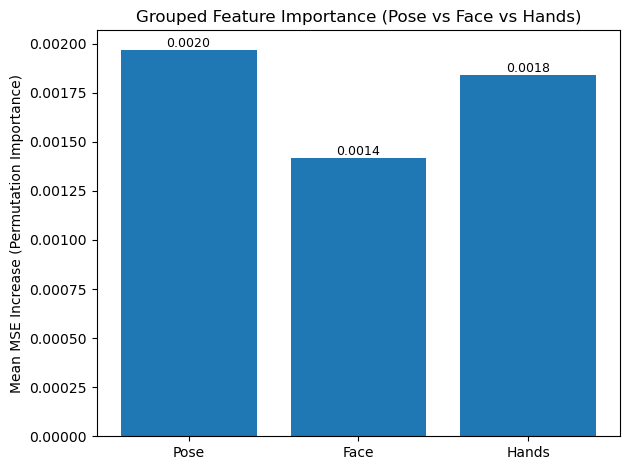

In [ ]:
# ===== FIGURE 4a: Grouped Permutation Importance (bar chart) =====
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_group_imp["Feature Group"], df_group_imp["Mean MSE Increase (↑)"])
plt.ylabel("Mean MSE Increase (Permutation Importance)")
plt.title("Grouped Feature Importance (Pose vs Face vs Hands)")
for i, v in enumerate(df_group_imp["Mean MSE Increase (↑)"].values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
# Optional: save to disk
# plt.savefig("outputs/fig_group_importance.png", dpi=300, bbox_inches="tight")
plt.show()

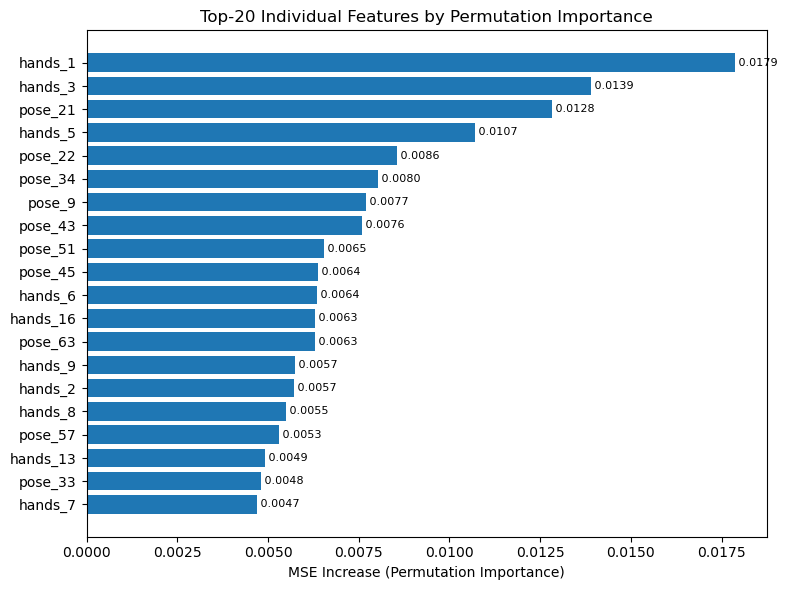

In [ ]:
# ===== FIGURE 4b (optional): Top-k Individual Features by Permutation Importance =====
# This helps drill down beyond Pose/Face/Hands groups.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build a feature name list matching your feature construction
POSE_DIM   = 33*3
FACE_DIM   = 10
HANDS_DIM  = importances.shape[0] - (POSE_DIM + FACE_DIM)  # handles on/off hands automatically

feat_names = (
    [f"pose_{i}" for i in range(POSE_DIM)] +
    [f"face_{i}" for i in range(FACE_DIM)] +
    ([f"hands_{i}" for i in range(HANDS_DIM)] if HANDS_DIM > 0 else [])
)

imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

TOP_K = 20  # adjust as needed
topk = imp_df.head(TOP_K).iloc[::-1]  # reverse for nicer horizontal bars (small to large)

plt.figure(figsize=(8, max(4, TOP_K*0.3)))
plt.barh(topk["feature"], topk["importance"])
plt.xlabel("MSE Increase (Permutation Importance)")
plt.title(f"Top-{TOP_K} Individual Features by Permutation Importance")
for i, v in enumerate(topk["importance"].values):
    plt.text(v, i, f" {v:.4f}", va="center", fontsize=8)
plt.tight_layout()
# Optional: save to disk
# plt.savefig("outputs/fig_topk_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ===========================
# TABLE 3: Ablation Study (fast baseline with Ridge regression)
# We test subsets of features (Pose / Pose+Face / Pose+Hands / All)
# against the SAME validation split for quick comparison.
# ===========================
from sklearn.linear_model import Ridge

# Define feature spans (must match construction)
POSE_DIM   = 33*3
FACE_DIM   = 10
HANDS_DIM  = X_all.shape[1] - (POSE_DIM + FACE_DIM)

spans = {
    "Pose only":           slice(0, POSE_DIM),
    "Pose + Face":         slice(0, POSE_DIM + FACE_DIM),
    "Pose + Hands":        np.r_[np.arange(0, POSE_DIM), np.arange(POSE_DIM+FACE_DIM, POSE_DIM+FACE_DIM+HANDS_DIM)],
    "Pose + Face + Hands": slice(0, X_all.shape[1]),
}

rows = []
for name, sl in spans.items():
    if isinstance(sl, slice):
        Xtr, Xv_ = X_tr[:, sl], X_v[:, sl]
    else:
        Xtr, Xv_ = X_tr[:, sl], X_v[:, sl]  # sl is an index array

    model_r = Ridge(alpha=1.0, random_state=42)
    model_r.fit(Xtr, y_tr)
    pred = model_r.predict(Xv_)
    mse, mae, r2, corr = metrics(y_v, pred)
    rows.append([name, mse, mae, r2, corr])

df_ablation = pd.DataFrame(rows, columns=["Configuration", "MSE ↓", "MAE ↓", "R² ↑", "Pearson r ↑"])
df_ablation

,Configuration,MSE ↓,MAE ↓,R² ↑,Pearson r ↑
0,Pose only,0.060978,0.201994,0.229896,0.480776
1,Pose + Face,0.059393,0.200297,0.249921,0.501126
2,Pose + Hands,0.053439,0.183766,0.325109,0.571708
3,Pose + Face + Hands,0.052294,0.182121,0.339572,0.584184


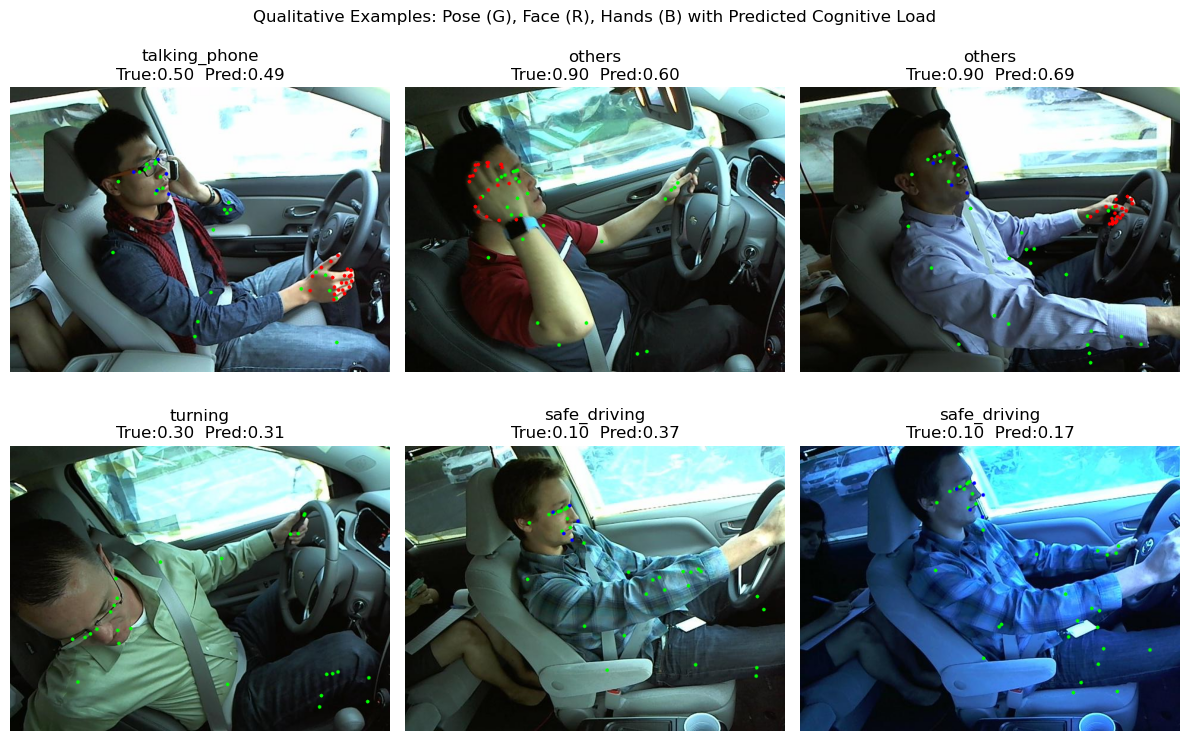

In [ ]:
# ===========================
# FIGURE 5: Qualitative Examples (overlay keypoints on frames)
# NOTE: This uses the *raw* (normalized) keypoints saved in pose_features_raw.csv
# and projects them to image coordinates for visualization.
# ===========================
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load raw features to recover per-image keypoints
df_raw = pd.read_csv(OUTPUT_DIR/"pose_features_raw.csv")

# Utility to draw points on an image (x,y normalized to [0,1])
def draw_points_on_image(img_bgr, coords_norm_xy, color=(0,255,0), radius=3, thickness=-1):
    h, w = img_bgr.shape[:2]
    img = img_bgr.copy()
    for (x, y) in coords_norm_xy:
        if x == 0 and y == 0:
            continue
        cx, cy = int(x * w), int(y * h)
        cv2.circle(img, (cx, cy), radius, color, thickness)
    return img

# Parse a row from df_raw to get pose / face / hands coords (normalized)
def parse_row_keypoints(row, face_pts=10, hands_pts=84):
    pose = row[[c for c in df_raw.columns if c.startswith("pose_")]].values
    # pose stored as [x,y,visibility]*33
    pose_xy = [(pose[i], pose[i+1]) for i in range(0, 33*3, 3)]

    face = row[[c for c in df_raw.columns if c.startswith("face_")]].values
    face_xy = [(face[i], face[i+1]) for i in range(0, face_pts, 2)] if len(face) >= face_pts else []

    hands_xy = []
    hand_cols = [c for c in df_raw.columns if c.startswith("hands_")]
    if len(hand_cols) >= hands_pts:
        hands = row[hand_cols].values
        hands_xy = [(hands[i], hands[i+1]) for i in range(0, hands_pts, 2)]

    return pose_xy, face_xy, hands_xy

# Pick a few validation examples (adjust N_EXAMPLES)
N_EXAMPLES = min(6, len(df_val))
sample_idx = df_val.sample(N_EXAMPLES, random_state=42).index

plt.figure(figsize=(12, 8))
for k, idx in enumerate(sample_idx, 1):
    img_path = df_val.loc[idx, "image_path"]
    true_val = df_val.loc[idx, "true"]
    pred_val = df_val.loc[idx, "pred"]
    beh = df_val.loc[idx, "behavior"]

    # find matching row in df_raw by path
    r = df_raw[df_raw["image_path"] == img_path]
    if r.empty:
        continue
    r = r.iloc[0]

    pose_xy, face_xy, hands_xy = parse_row_keypoints(r)

    img = cv2.imread(img_path)
    if img is None:
        continue
    img = draw_points_on_image(img, pose_xy, color=(0,255,0))
    img = draw_points_on_image(img, face_xy, color=(255,0,0))
    if len(hands_xy) > 0:
        img = draw_points_on_image(img, hands_xy, color=(0,0,255))

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(int(np.ceil(N_EXAMPLES/3)), 3, k)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{beh}\nTrue:{true_val:.2f}  Pred:{pred_val:.2f}")

plt.suptitle("Qualitative Examples: Pose (G), Face (R), Hands (B) with Predicted Cognitive Load")
plt.tight_layout()
plt.show()

In [ ]:
# ===========================
# (Optional) Confidence Intervals via Bootstrap for Pearson r
# ===========================
import numpy as np

def bootstrap_corr(y_true, y_pred, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    corrs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        corrs.append(np.corrcoef(y_true[idx], y_pred[idx])[0,1])
    corrs = np.array(corrs)
    lo, hi = np.percentile(corrs, [2.5, 97.5])
    return float(np.mean(corrs)), float(lo), float(hi)

mean_r, lo_r, hi_r = bootstrap_corr(df_val["true"].values, df_val["pred"].values, n_boot=1000, random_state=42)
print(f"Pearson r (bootstrap): mean={mean_r:.3f}, 95% CI=({lo_r:.3f}, {hi_r:.3f})")

Pearson r (bootstrap): mean=0.799, 95% CI=(0.773, 0.825)


In [ ]:
# ===========================
# (Optional) Paired Significance Test vs Baseline
# Compares absolute errors of our model vs a baseline predictor.
# If your 'true' labels equal class mapping, the rule-based baseline equals truth (no diff).
# Use the constant-mean baseline for a sensible comparison here.
# ===========================
from scipy.stats import wilcoxon
import numpy as np

# Our absolute errors
ae_ours = np.abs(df_val["pred"].values - df_val["true"].values)

# Baseline: constant mean of the validation set
const_mean = np.full_like(df_val["true"].values, df_val["true"].mean(), dtype=float)
ae_base = np.abs(const_mean - df_val["true"].values)

# Wilcoxon signed-rank test (paired)
stat, pval = wilcoxon(ae_ours, ae_base, zero_method="wilcox", alternative="less")
print(f"Wilcoxon paired test (ours < baseline): stat={stat:.3f}, p={pval:.3e}")

Wilcoxon paired test (ours < baseline): stat=121315.500, p=1.246e-143


In [ ]:
# ===========================
# (Optional) Results Export Helpers
# Save key tables as CSVs to include in the paper
# ===========================
(df_perf).to_csv(OUTPUT_DIR/"table_overall_performance.csv", index=False)
(per_class).to_csv(OUTPUT_DIR/"table_per_class_means.csv", index=False)
(df_ablation).to_csv(OUTPUT_DIR/"table_ablation_ridge.csv", index=False)

print("Saved tables to:", OUTPUT_DIR.resolve())

Saved tables to: C:\Users\Jisan\Downloads\outputs
